>>> Wczytano wektor kwantowy o kształcie (563, 15)

>>> Start optymalizacji Walk-Forward (Random Forest)...

--- UCZCIWE WYNIKI RANDOM FOREST OOS ---
Accuracy: 0.5225 (bez optymalizacji progu)
AUC ROC:  0.5317

--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---
1. Q1_HUB_X: 0.0767
2. Q3_Sat_X: 0.0759
3. Q1_HUB_Y: 0.0749
4. Q2_Sat_Z: 0.0697
5. Q2_Sat_X: 0.0695


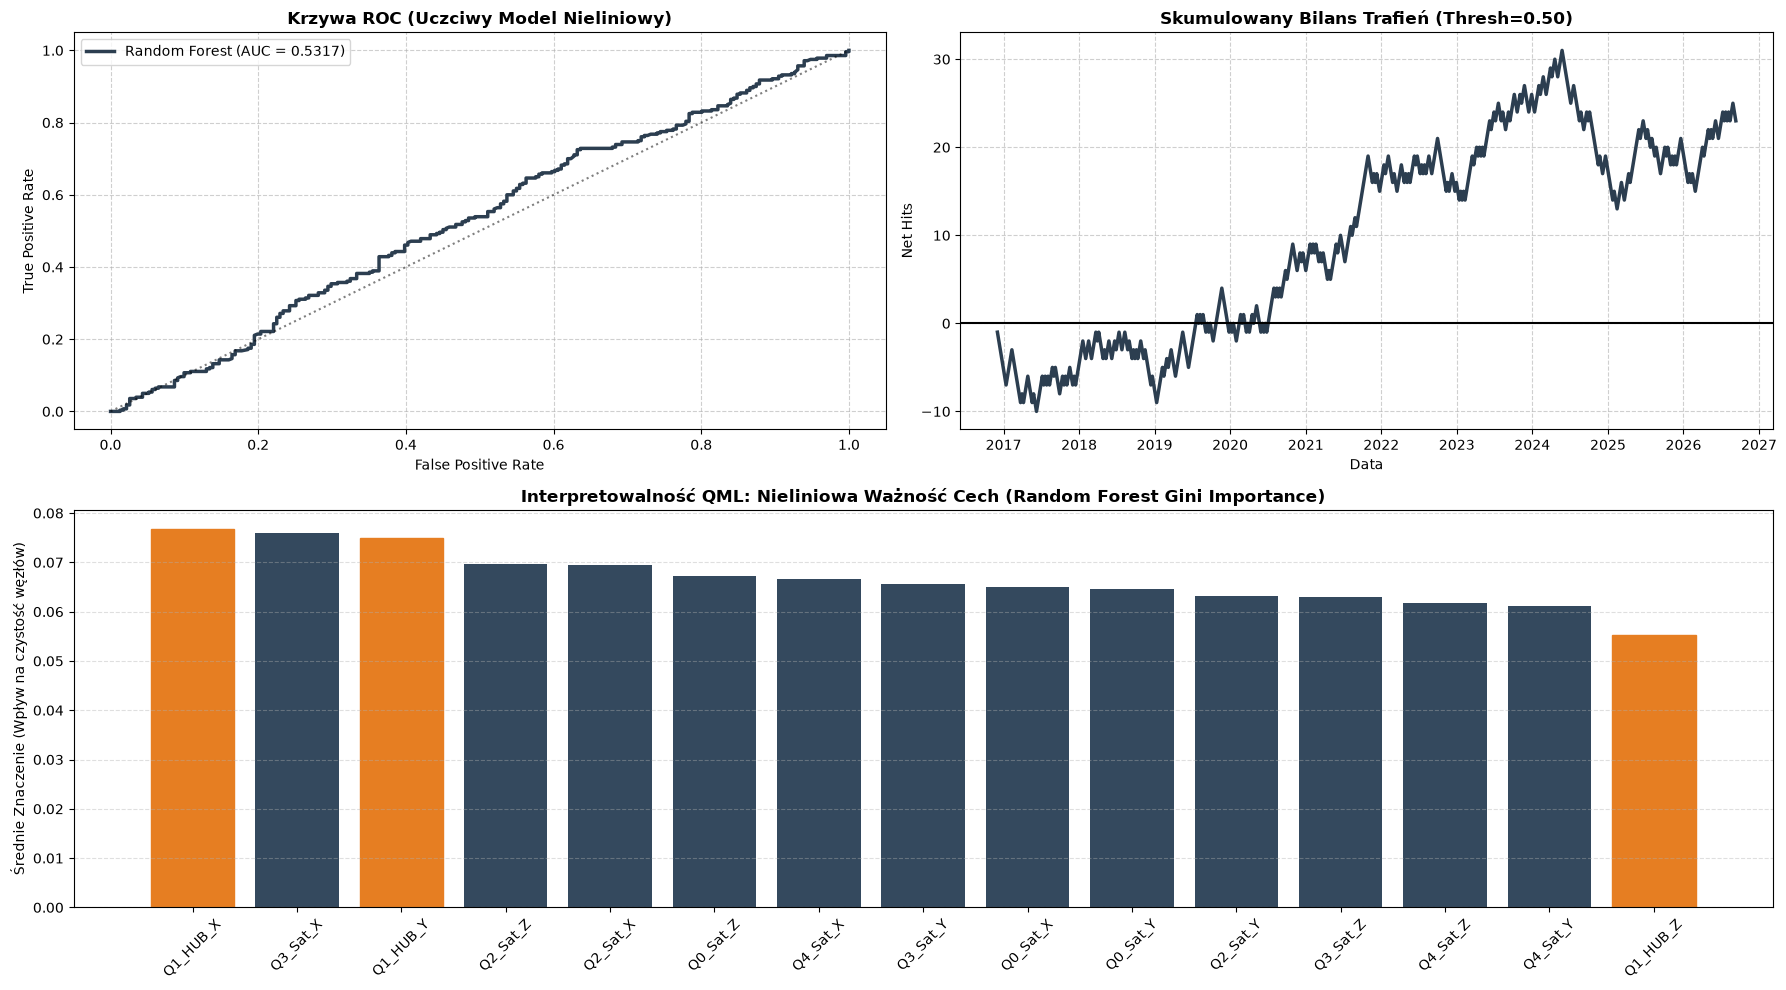

In [2]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA PLIKÓW I DANYCH
# ==========================================
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

if not os.path.exists(PLIK_KACHE):
    raise FileNotFoundError(f"Nie znaleziono pliku {PLIK_KACHE}.")

loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)
first_key = loaded_archive.files[0]
Phi_real = loaded_archive[first_key]

print(f">>> Wczytano wektor kwantowy o kształcie {Phi_real.shape}")

FEATURE_NAMES = [
    "Q0_Sat_X", "Q0_Sat_Y", "Q0_Sat_Z",
    "Q1_HUB_X", "Q1_HUB_Y", "Q1_HUB_Z",
    "Q2_Sat_X", "Q2_Sat_Y", "Q2_Sat_Z",
    "Q3_Sat_X", "Q3_Sat_Y", "Q3_Sat_Z",
    "Q4_Sat_X", "Q4_Sat_Y", "Q4_Sat_Z"
]

# ==========================================
# 2. TRENOWANIE KROCZĄCE: RANDOM FOREST
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (Random Forest)...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)

pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Siatka hiperparametrów dostosowana do drzew
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [3, 5, None],
    "rf__min_samples_leaf": [1, 3]
}

results = {"y_true": [], "dates": [], "prob": []}
feature_importances_history = []

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_tr, y_tr)
    
    best_model = search.best_estimator_
    results["prob"].append(best_model.predict_proba(X_te)[0, 1])
    
    # Wyciąganie znaczenia cech z wygranego Lasu Losowego
    importances = best_model.named_steps["rf"].feature_importances_
    feature_importances_history.append(importances)

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

# SZTYWNY PRÓG 0.5 - Koniec ze sztucznym pompowaniem Accuracy!
final_preds = (prob_preds > 0.55).astype(int)
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, prob_preds)

# ==========================================
# 3. ANALIZA WAŻNOŚCI CECH (NIELINIOWA)
# ==========================================
avg_importances = np.mean(feature_importances_history, axis=0)

sorted_idx = np.argsort(avg_importances)[::-1]
sorted_features = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_importances = avg_importances[sorted_idx]

print(f"\n--- UCZCIWE WYNIKI RANDOM FOREST OOS ---")
print(f"Accuracy: {acc:.4f} (bez optymalizacji progu)")
print(f"AUC ROC:  {auc:.4f}")

print("\n--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---")
for i in range(5):
    print(f"{i+1}. {sorted_features[i]}: {sorted_importances[i]:.4f}")

# ==========================================
# 4. WIZUALIZACJA
# ==========================================
fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax1.plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'Random Forest (AUC = {auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax1.set_title('Krzywa ROC (Uczciwy Model Nieliniowy)', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax2.plot(results["dates"], net_hits, color='#2c3e50', lw=2.5)
ax2.axhline(0, color='black', lw=1.5)
ax2.set_title(f'Skumulowany Bilans Trafień (Thresh=0.50)', fontweight='bold')
ax2.set_xlabel('Data')
ax2.set_ylabel('Net Hits')
ax2.grid(True, linestyle='--', alpha=0.6)

bars = ax3.bar(sorted_features, sorted_importances, color='#34495e')
for i, bar in enumerate(bars):
    if "HUB" in sorted_features[i]:
        bar.set_color('#e67e22') 
        
ax3.set_title('Interpretowalność QML: Nieliniowa Ważność Cech (Random Forest Gini Importance)', fontweight='bold')
ax3.set_ylabel('Średnie Znaczenie (Wpływ na czystość węzłów)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()